# SINASC 2024 — ML preditivo e AIPW

## 1. Perguntas da Fase 2

**Predição:** quem apresenta maior risco de baixo peso?

**Causal:** qual a diferença média de risco sob início precoce versus tardio, sob as hipóteses observacionais?

Este exercício compara duas perguntas distintas. Os resultados causais são condicionais a hipóteses fortes e não provam causalidade.


In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from IPython.display import display, Markdown, Image

raiz = next(p for p in (Path.cwd(), Path.cwd().parent) if (p/'src').exists()).resolve()
sys.path.insert(0, str(raiz))
from src.visualizacao_ipt import aplicar_tema_ipt, configurar_plotly
configurar_plotly()
pio.renderers.default = 'png'
pasta = raiz/'outputs/diagnostics'
pred = json.loads((pasta/'fase2_modelagem_preditiva.json').read_text(encoding='utf-8'))
causal = json.loads((pasta/'fase2_aipw.json').read_text(encoding='utf-8'))
sens = json.loads((pasta/'fase2_sensibilidades.json').read_text(encoding='utf-8'))
assert causal['provenance']['n'] == pred['n'] == 2251570
assert causal['efeito_causal_estimado'] and not causal['causalidade_provada']
assert sum(f['n_validacao'] for f in causal['folds']) == pred['n']
assert all(f['intersecao'] == 0 for f in causal['folds'])

def mostrar(fig, titulo, arquivo):
    aplicar_tema_ipt(fig, titulo)
    fig.update_layout(width=1100, height=650, margin=dict(l=100, r=50, t=90, b=100))
    fig.update_yaxes(automargin=True)
    fig.write_html(raiz/'outputs/figures'/arquivo, include_plotlyjs=True)
    png = (raiz/'outputs/figures'/arquivo).with_suffix('.png')
    fig.write_image(png)
    display(Image(filename=str(png)))

print('Resultados da amostra integral; recalcular na .venv com: python -m src.executa_fase2')
print('Gate:', causal['gate'])


Resultados da amostra integral; recalcular na .venv com: python -m src.executa_fase2
Gate: RESULTADO_NAO_INTERPRETAVEL


## Síntese dos resultados executados

A discriminação preditiva foi limitada (ROC-AUC 0,574 logística; 0,583 HGB), com calibração por decis próxima da diagonal. AIPW: C1 −1,341 pp e C2 −1,231 pp; as sensibilidades de suporte mudaram pouco os valores.

O gate conservador é **RESULTADO_NAO_INTERPRETAVEL**: os 1% maiores |IF| concentram 78,8% de IF², acima do limite pré-especificado de 50%. Esse limiar do exercício não é um teste universal de invalidade. A contribuição individual máxima é ~0,0015 pp e o ESS dos controles ~232.772; estes contrapontos e a estabilidade numérica também devem ser considerados na revisão. Não afirmar causalidade provada.


## 2. População congelada

SINASC 2024: gestações únicas, peso 500–6.000 g, mês de início do pré-natal válido. O checkpoint da Fase 1 está documentado no plano. Sem exclusão complete-case e sem trimming oculto.

## 3. X, T e Y

T=1: meses 1–3; T=0: meses 4–9. Y=1: peso <2.500 g.

X: idade, escolaridade, raça/cor, situação conjugal, paridade, perdas fetais e UF maternas. Números de consultas, idade gestacional, parto, Apgar e estabelecimento ficam fora do ajuste.


In [2]:
display(pd.DataFrame([causal['provenance']]).T)

,0
python,3.11.9
sklearn,1.8.0
seed,20240925
n,2251570
chave,contador
ordem,contador
parquet_sha256,a7a1618e555d1417f692b5334b2a0fd01cfee911b3d45c...
datas_nascimento,"{'minimo': '01012024', 'maximo': '31122024', '..."
x,"[IDADEMAE_NUM, ESCOLARIDADE_MAE, RACA_COR_MAE,..."
t,MESPRENAT 1-3 versus 4-9


## 4. ASSOCIAÇÃO BRUTA — NÃO CAUSAL

A diferença entre os grupos observados mistura tratamento, composição e confundimento. Ela é apresentada antes do ajuste apenas como descrição.


In [3]:
display(pd.DataFrame([causal['associacao_bruta']]))

,rotulo,risco_t1,risco_t0,diferenca_pp
0,ASSOCIAÇÃO BRUTA — NÃO CAUSAL,0.076992,0.09123,-1.423859


## 5. Benchmark preditivo

Split 80/20 estratificado por Y; seed fixa. Mesmas sete X, sem T. PR-AUC aqui é average precision. Precision, recall e F1 usam limiar 0,5, não otimizado no teste. Calibração usa decis de probabilidade; não houve recalibração no teste.


In [4]:
metricas = ['modelo', 'roc_auc', 'pr_auc_ap', 'brier', 'precision_05', 'recall_05', 'f1_05', 'prevalencia', 'media_predita']
display(pd.DataFrame(pred['modelos'])[metricas].round(6))
print('N treino:', pred['n_treino'], '| N teste:', pred['n_teste'])
print('Brier baseline:', pred['brier_baseline_prevalencia_treino'])


,modelo,roc_auc,pr_auc_ap,brier,precision_05,recall_05,f1_05,prevalencia,media_predita
0,logistica,0.574248,0.100220,0.072350,0.0,0.0,0.0,0.078949,0.078929
1,hgb,0.583494,0.104537,0.072239,0.0,0.0,0.0,0.078949,0.078902


N treino: 1801256 | N teste: 450314
Brier baseline: 0.07271635463062807


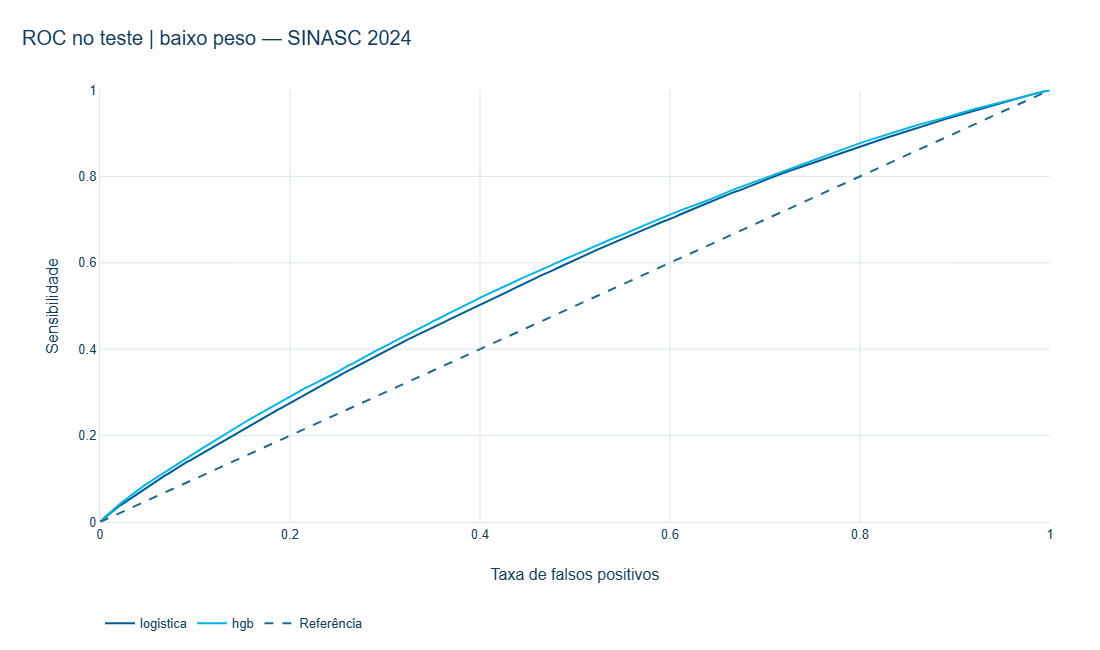

In [5]:
fig = go.Figure()
for modelo in pred['modelos']:
    fig.add_scatter(x=modelo['roc']['x'], y=modelo['roc']['y'], mode='lines', name=modelo['modelo'])
fig.add_scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash'), name='Referência')
fig.update_xaxes(title='Taxa de falsos positivos', range=[0,1])
fig.update_yaxes(title='Sensibilidade', range=[0,1])
mostrar(fig, 'ROC no teste | baixo peso — SINASC 2024', 'fase2_roc.html')


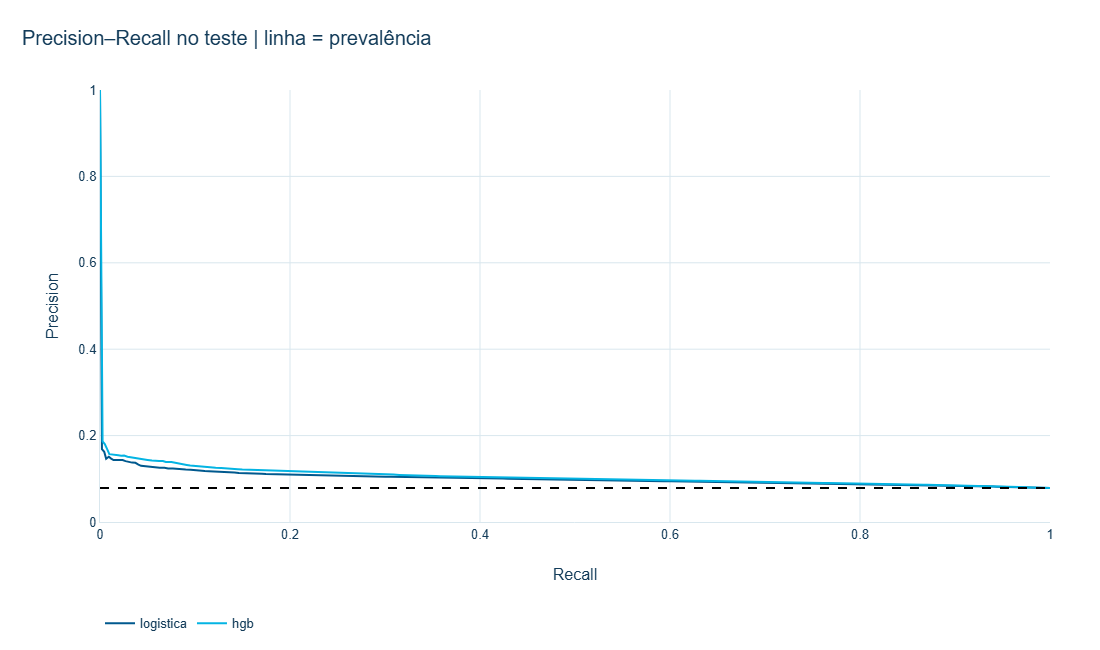

In [6]:
fig = go.Figure()
for modelo in pred['modelos']:
    fig.add_scatter(x=modelo['pr']['x'], y=modelo['pr']['y'], mode='lines', name=modelo['modelo'])
fig.add_hline(y=pred['modelos'][0]['prevalencia'], line_dash='dash')
fig.update_xaxes(title='Recall', range=[0,1])
fig.update_yaxes(title='Precision', range=[0,1])
mostrar(fig, 'Precision–Recall no teste | linha = prevalência', 'fase2_pr.html')


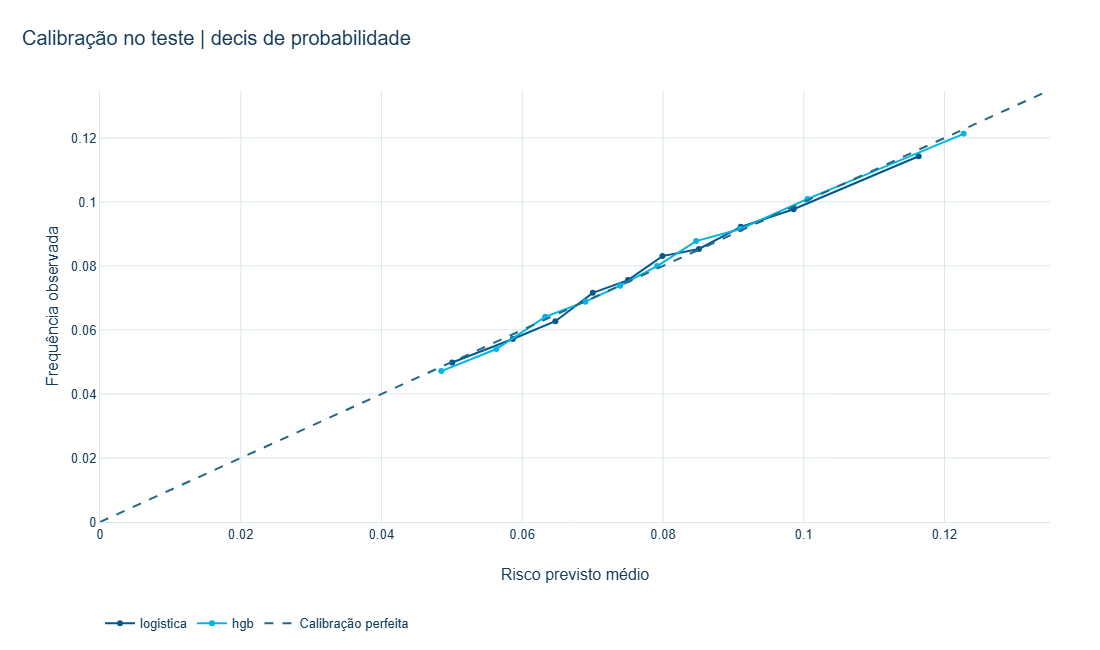

In [7]:
fig = go.Figure()
for modelo in pred['modelos']:
    c = modelo['calibracao']
    fig.add_scatter(x=c['previsto'], y=c['observado'], mode='lines+markers', name=modelo['modelo'])
lim = max(max(m['calibracao']['previsto'] + m['calibracao']['observado']) for m in pred['modelos'])*1.1
fig.add_scatter(x=[0,lim], y=[0,lim], mode='lines', line=dict(dash='dash'), name='Calibração perfeita')
fig.update_xaxes(title='Risco previsto médio', range=[0,lim])
fig.update_yaxes(title='Frequência observada', range=[0,lim])
mostrar(fig, 'Calibração no teste | decis de probabilidade', 'fase2_calibracao.html')


## 6. Por que predição não é efeito causal

Um modelo de risco aprende quem apresenta Y. Um efeito compara outcomes potenciais sob ações diferentes. Boa AUC não elimina confundimento; baixa AUC de Y não invalida por si só um estimador de efeito.

## 7. AIPW em linguagem simples

O estimador combina previsões de risco sob cada tratamento e correções dos resíduos ponderadas pela probabilidade do tratamento recebido.

`psi = m1 − m0 + T(Y−m1)/e − (1−T)(Y−m0)/(1−e)`

A média de psi é a diferença estimada de risco. SE = desvio-padrão de (psi−média) / √N; IC95% = estimativa ±1,96 SE. A dupla robustez não garante resultado correto quando ambos os modelos são inadequados ou há confundimento não observado.

## 8. Cross-fitting

Três folds estratificados por T/Y, sem sobreposição. Codificadores e imputação ajustados dentro de cada treino. Cada registro recebe exatamente uma previsão OOF de cada nuisance. C1 e C2 compartilham o propensity logístico.


In [8]:
display(pd.DataFrame([{k:v for k,v in f.items() if k != 'ajustes'} for f in causal['folds']]))
ajustes = [dict(fold=f['fold'], modelo=nome, n_iter=v['n_iter'], convergence_warning=v['convergence_warning'])
           for f in causal['folds'] for nome,v in f['ajustes'].items()]
display(pd.DataFrame(ajustes))
print('AUC propensity OOF, descritiva:', causal['auc_propensity_oof'])


,fold,n_treino,n_validacao,intersecao,sha256_indices_validacao
0,1,1501046,750524,0,7f3e8c1a6dde4e237cfb94c853a9d2a054d51acbd0128d...
1,2,1501047,750523,0,84be7b11bff9a9ae2deadef5efc540e25c91bd068cb38a...
2,3,1501047,750523,0,89d0f573614f528c90cad8ea55921e7445e9bd7e032e3f...


,fold,modelo,n_iter,convergence_warning
0,1,e,51,False
1,1,m0_C1,59,False
2,1,m1_C1,56,False
3,1,m0_C2,45,False
4,1,m1_C2,98,False
5,2,e,50,False
6,2,m0_C1,70,False
7,2,m1_C1,54,False
8,2,m0_C2,52,False
9,2,m1_C2,100,False


AUC propensity OOF, descritiva: 0.6628622758850582


## 9. C1: baseline paramétrico

Propensity e outcomes logísticos L2. Resultado em pontos percentuais; IC aproximado por função de influência.


In [9]:
resultados = pd.DataFrame(causal['resultados'])
colunas = ['especificacao', 'populacao', 'n', 'estimativa_pp', 'se_pp', 'ic95_inferior_pp', 'ic95_superior_pp']
display(resultados.loc[(resultados.especificacao == 'C1') & (resultados.populacao == 'sem_trimming'), colunas])


,especificacao,populacao,n,estimativa_pp,se_pp,ic95_inferior_pp,ic95_superior_pp
0,C1,sem_trimming,2251570,-1.340527,0.061994,-1.462034,-1.219019


## 10. C2: outcomes não lineares

Propensity logístico compartilhado; m0/m1 por HistGradientBoosting. Nenhuma especificação foi selecionada por produzir efeito maior ou menor.


In [10]:
display(resultados.loc[(resultados.especificacao == 'C2') & (resultados.populacao == 'sem_trimming'), colunas])

,especificacao,populacao,n,estimativa_pp,se_pp,ic95_inferior_pp,ic95_superior_pp
3,C2,sem_trimming,2251570,-1.231456,0.061981,-1.352938,-1.109973


## 11. Sensibilidade ao suporte

Trimming muda a população-alvo. Os intervalos 0,01–0,99 e 0,05–0,95 são sensibilidades. Os ICs tratam a seleção pelo propensity aprendido como fixa; não incluem essa incerteza adicional.


,especificacao,populacao,n,estimativa_pp,se_pp,ic95_inferior_pp,ic95_superior_pp
0,C1,sem_trimming,2251570,-1.340527,0.061994,-1.462034,-1.219019
1,C1,0.01_0.99,2251570,-1.340527,0.061994,-1.462034,-1.219019
2,C1,0.05_0.95,2103319,-1.382662,0.060840,-1.501907,-1.263416
3,C2,sem_trimming,2251570,-1.231456,0.061981,-1.352938,-1.109973
4,C2,0.01_0.99,2251570,-1.231456,0.061981,-1.352938,-1.109973
5,C2,0.05_0.95,2103319,-1.273369,0.060813,-1.392563,-1.154175


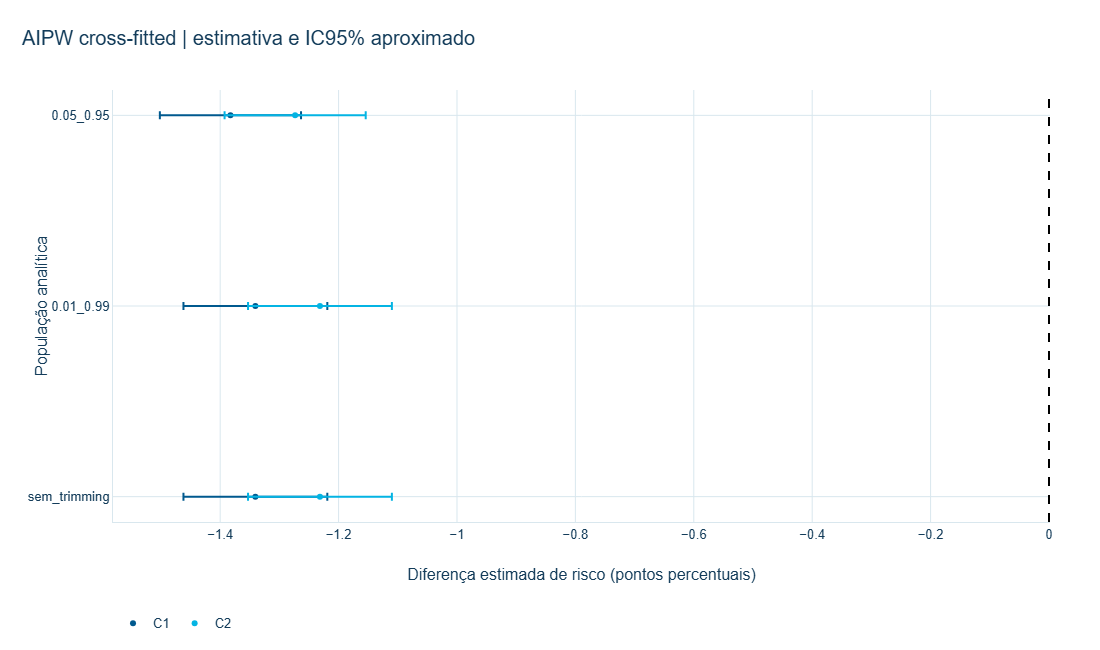

In [11]:
display(resultados[colunas].round(6))
fig = go.Figure()
for spec in ['C1','C2']:
    d = resultados[resultados.especificacao == spec]
    fig.add_scatter(x=d.estimativa_pp, y=d.populacao, mode='markers', name=spec,
                    error_x=dict(type='data', array=1.96*d.se_pp, visible=True))
fig.add_vline(x=0, line_dash='dash')
fig.update_xaxes(title='Diferença estimada de risco (pontos percentuais)')
fig.update_yaxes(title='População analítica')
mostrar(fig, 'AIPW cross-fitted | estimativa e IC95% aproximado', 'fase2_aipw.html')


## 12. Diagnósticos do estimador

ESS descreve a concentração dos pesos, não o número real de pessoas. A concentração de IF² nos extremos é verificada pelo gate pré-especificado. Percentis de psi e IF estão no JSON integral.


In [12]:
linhas = []
for chave, d in causal['diagnosticos'].items():
    linhas.append(dict(cenario=chave, fracao_variancia_top1pct=d['frac_variancia_top1pct'],
                       max_abs_IF=d['max_abs_influencia'], max_contribuicao_pp=d['max_contribuicao_individual_pp'],
                       ESS_T0=d['pesos_por_grupo']['0']['ess'], ESS_T1=d['pesos_por_grupo']['1']['ess'],
                       peso_max_T0=d['pesos_por_grupo']['0']['max']))
display(pd.DataFrame(linhas).round(6))
display(pd.DataFrame(causal['overlap']['trimming_diagnostico']))
display(pd.DataFrame([dict(especificacao=s, nuisance=k, **v)
                      for s, modelos in causal['nuisance_oof'].items() for k,v in modelos.items()]).round(6))


,cenario,fracao_variancia_top1pct,max_abs_IF,max_contribuicao_pp,ESS_T0,ESS_T1,peso_max_T0
0,C1_sem_trimming,0.787812,33.731018,0.001498,232772.240802,1.927133e+06,38.791759
1,C1_0.01_0.99,0.787812,33.731018,0.001498,232772.240802,1.927133e+06,38.791759
2,C1_0.05_0.95,0.761472,19.011481,0.000904,244237.072311,1.787300e+06,19.995383
3,C2_sem_trimming,0.787666,32.044979,0.001423,232772.240802,1.927133e+06,38.791759
4,C2_0.01_0.99,0.787666,32.044979,0.001423,232772.240802,1.927133e+06,38.791759
5,C2_0.05_0.95,0.760897,19.067730,0.000907,244237.072311,1.787300e+06,19.995383


,regra,limite_inferior,limite_superior,n_total,n_mantido,n_excluido,n_tratado_mantido,n_controle_mantido,n_tratado_excluido,n_controle_excluido
0,sem_trimming,0.00,1.00,2251570,2251570,0,1942045,309525,0,0
1,0.01_0.99,0.01,0.99,2251570,2251570,0,1942045,309525,0,0
2,0.05_0.95,0.05,0.95,2251570,2103319,148251,1800499,302820,141546,6705


,especificacao,nuisance,roc_auc,pr_auc_ap,brier,precision_05,recall_05,f1_05,limiar,prevalencia,media_predita
0,C1,m0_grupo_observado,0.583803,0.120885,0.082281,0.0,0.0,0.0,0.5,0.091230,0.091214
1,C1,m1_grupo_observado,0.571815,0.096928,0.070736,0.0,0.0,0.0,0.5,0.076992,0.076991
2,C2,m0_grupo_observado,0.588761,0.122982,0.082204,0.0,0.0,0.0,0.5,0.091230,0.091225
3,C2,m1_grupo_observado,0.580691,0.101489,0.070630,0.0,0.0,0.0,0.5,0.076992,0.076993


## 13. Limitações

Dados observacionais: faltam renda, tabagismo, nutrição, morbidades prévias, planejamento da gravidez e medidas de acesso/qualidade. X no nascimento é proxy de estado prévio. Timing retrospectivo e discordâncias de consultas podem causar erro de classificação.

Seleção por nascido vivo, informação e limites de peso pode induzir viés. Não extrapolar para todas as concepções. SE iid não considera dependência geográfica/familiar nem incerteza de identificação. Significância estatística não demonstra causalidade. Nenhum placebo/negative control adequado foi identificado; heterogeneidade foi omitida.

## 14. Gate analítico

O gate usa as regras declaradas no plano anterior à estimação. Não é certificação de causalidade verdadeira.


In [13]:
display(Markdown('**'+causal['gate']+'**')); print('EFEITO_CAUSAL_ESTIMADO = SIM; CAUSALIDADE_PROVADA = NAO')

**RESULTADO_NAO_INTERPRETAVEL**

EFEITO_CAUSAL_ESTIMADO = SIM; CAUSALIDADE_PROVADA = NAO
